### Langchain version v1

In [1]:
import langchain
print(langchain.__version__)

1.3.1


In [2]:
import os
from dotenv import load_dotenv

In [3]:
load_dotenv()
gemini = os.getenv("GEMINI_API_KEY")
Groq_API_Key = os.getenv("GROQ_API_KEY")

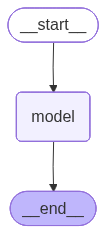

In [4]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

llm = init_chat_model(
    model="google_genai:gemini-2.0-flash",
    # model_provider="google_genai"
)

agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="You are a senior software engineer"
)

agent

## Adding a tool with agent

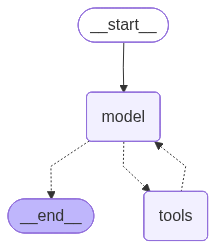

In [5]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from datetime import datetime

llm = init_chat_model(
    model = "google_genai:gemini-2.5-flash",
    # model_provider = "google_genai"
)

# Tool 1
def get_current_time(city:str)->str:
    """This is retuning current time of a city"""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Tool 2
def get_weather(city:str)->str:
    """This is retuning current weather of a city"""
    return f"The current weather in {city} is sunny"


agent = create_agent(
    model = "google_genai:gemini-2.5-flash",
    tools = [get_current_time, get_weather],
    system_prompt = "You are a senior software engineer"
)
agent

In [6]:
response = agent.invoke({
    "messages": [{
        "role": "user", 
        "content": "What is the current time of Jeddah"
        }]
    })

# We can avoid roles and directly pass the query to the agent
# response = agent.invoke("What is the current time of Jeddah")

In [7]:
query = response["messages"][0].content
output = response["messages"][-1].content
print(f"For the query: {query}, the agent responded with: {output}")

For the query: What is the current time of Jeddah, the agent responded with: The current time in Jeddah is 19:10:40 on June 13, 2026.


# Model Integration with GEMINI and GROQ

## Gemini Integration

In [8]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model = "google_genai:gemini-2.5-flash"
)
response = model.invoke("What is langsmith?")
response.content

'**LangSmith** is a **platform developed by the creators of LangChain** that provides a comprehensive suite of tools for **building, debugging, testing, evaluating, and monitoring Large Language Model (LLM) applications** throughout their entire lifecycle.\n\nThink of it as the **"observability and MLOps platform" for your LLM applications**, especially those built with LangChain, but increasingly useful for any LLM-powered system.\n\n---\n\nHere\'s a breakdown of what LangSmith is and why it\'s crucial:\n\n## The Problem LangSmith Solves\n\nBuilding applications with LLMs (especially complex ones involving chains, agents, and tools) presents several unique challenges:\n\n1.  **Lack of Visibility:** It\'s hard to see what\'s happening "inside" an LLM call or a complex chain. What prompt was actually sent? What was the exact response? Which tools were invoked? What were the intermediate steps?\n2.  **Non-Determinism:** LLMs are not deterministic. The same prompt can yield different resu

We can also use their dedicated libraries, used in large and complex scope problems

In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash"
)
response = model.invoke("In few lines, what is langsmith?")
response.content

'LangSmith is a platform for **developing, debugging, testing, and monitoring** Large Language Model (LLM) applications.\n\nIt provides **observability** into your LLM chains and agents, allowing you to **trace execution, identify issues, and evaluate performance**. Essentially, it helps developers **build and iterate on reliable AI applications** more effectively.'

## GROQ Model Integration

1- Use init_chat_model  
2- Use Groq Library

In [10]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model="groq:qwen/qwen3-32b",
    reasoning_effort="none"
)
response = model.invoke("Like langsmith, is there any framework for computer vision?")
response.content

"Yes, just like **LangSmith** for **language models**, there are several **frameworks and toolkits** tailored for **Computer Vision (CV)** that provide tools for data management, model development, evaluation, and deployment. Below is a categorization of such frameworks, including both **model development libraries** and **ML ops platforms** for computer vision.\n\n---\n\n## 🧠 **1. ML Ops Platforms for Computer Vision**\n\nThese are **CV-specific ML ops platforms** that provide tools for annotation, training, evaluation, monitoring, and deployment — similar to LangSmith but for Vision AI.\n\n| Framework | Description |\n|-----------|-------------|\n| **CVAT (Computer Vision Annotation Tool)** | Open-source data labeling tool for computer vision. Supports video and image annotation, integrates with many model training pipelines. |\n| **Label Studio** | Multimodal labeling tool (supports computer vision), allows custom ML model integration, easy to deploy. |\n| **SuperAnnotate** | SaaS-b

In [11]:
from langchain_groq import ChatGroq
model = ChatGroq(
    model="qwen/qwen3-32b",
    # api_key=Groq_API_Key,
    reasoning_effort="none"
)
response = model.invoke("In few words,Like langsmith, is there any framework for computer vision?")
response.content

"Yes, **LangChain** has a **computer vision counterpart** called **LangVision**, but more broadly, there are several frameworks and tools analogous to **LangSmith** for **computer vision**, especially for **development, evaluation, and deployment** of vision models.\n\nHere are a few **frameworks and tools for computer vision** that serve similar roles to **LangSmith**:\n\n---\n\n### 📸 **Computer Vision Frameworks / Tools (Equivalent to LangSmith)**\n\n| Tool | Description |\n|------|-------------|\n| **Weights & Biases (WandB)** | Tracking experiments, logging metrics, visualizing images, and managing ML workflows — supports computer vision. |\n| **MMDetection** | A detection framework built on PyTorch, used for object detection and segmentation. |\n| **Detectron2** | Facebook AI's library for modern computer vision research. |\n| **Label Studio** | Open-source data labeling tool supporting image, video, and text annotation — useful for dataset preparation. |\n| **CVAT (Computer Visio

## Streaming
To avaoid waiting for complete output to be displayed, we can use stream to simultaneous print generated output

In [58]:
model.stream("In few lines, Why do cats meow?")

<generator object BaseChatModel.stream at 0x7076ba22aec0>

In [60]:
#To display it, we will use loop
for chunk in model.stream("In few lines, Why do cats meow?"):
    print(chunk.content, end="|", flush=True)

|C|ats| me|ow| primarily| to| communicate| with| humans|,| as| adult| cats| rarely| me|ow| at| each| other|.| They| use| me|owing| to| express| needs|,| desires|,| greetings|,| or| discomfort|,| making| it| a| versatile| vocal| tool| in| their| interaction| with| people|.|||

## Batch
To reduce api cost and enhance performance, batch allow us to pass mulitple prompts togeather

In [63]:
responses = model.batch([
    "Briefly tell about  quantum computing",
    "What is the capital of France?"
])
# responses
for response in responses:
    print(response.content, end="\n")

Quantum computing is a type of computing that uses **quantum bits (qubits)**, which can exist in multiple states simultaneously due to the principles of **superposition** and **entanglement**. Unlike classical computers that use bits (0 or 1), quantum computers can process complex calculations exponentially faster for certain problems, such as:

- **Factorizing large numbers** (important for cryptography),  
- **Simulating quantum systems** (useful in chemistry and materials science),  
- **Optimization problems** in logistics, finance, and machine learning.

Quantum computing is still in early stages, with challenges like **qubit stability** and **error correction**, but it holds transformative potential for fields like drug discovery, AI, and secure communications. Major companies like IBM, Google, and startups are actively developing quantum technologies.
The capital of France is Paris.


In [64]:
# we can limit the parallel requests by passing the parameter `max_concurrent_requests`
responses = model.batch(
    [
        "Briefly tell about  quantum computing",
        "What is the capital of France?"
    ],
    config={"max_concurrent_requests": 3}
)
# responses
for response in responses:
    print(response.content, end="\n\n")

Quantum computing is a type of computing that uses quantum-mechanical phenomena, such as superposition and entanglement, to perform operations on data. Unlike classical computers, which use bits as their smallest unit of data (either 0 or 1), quantum computers use **qubits** (quantum bits), which can exist in **superpositions** of both 0 and 1 simultaneously.

This allows quantum computers to process vast amounts of information in parallel, making them potentially much faster than classical computers for specific tasks, such as:

- Factoring large numbers (important for cryptography)
- Simulating quantum systems (useful in chemistry and materials science)
- Solving optimization problems
- Machine learning and data analysis

Key quantum concepts include:

- **Superposition**: A qubit can be in multiple states at once.
- **Entanglement**: Qubits can be linked so that the state of one instantly affects the state of another, no matter the distance.
- **Quantum Interference**: Used to ampli

## Tools

In [12]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather of a location"""
    return f"The weather in {location} is sunny."

model_with_tool = model.bind_tools([get_weather])
response = model_with_tool.invoke("What is the weather in Jeddah?")
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2g4jwb6ex', 'function': {'arguments': '{"location":"Jeddah"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 159, 'total_tokens': 181, 'completion_time': 0.027641385, 'completion_tokens_details': None, 'prompt_time': 0.006367808, 'prompt_tokens_details': None, 'queue_time': 0.243030783, 'total_time': 0.034009193}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'service_tier': 'on_demand', 'reasoning_effort': 'none', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ec1c3-0b58-7b10-b5c8-592ed624415b-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Jeddah'}, 'id': '2g4jwb6ex', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 159, 'output_tokens': 22, 'total_tokens': 181})

In [13]:
print(response.tool_calls)

[{'name': 'get_weather', 'args': {'location': 'Jeddah'}, 'id': '2g4jwb6ex', 'type': 'tool_call'}]


In [14]:
for tool_call in response.tool_calls:
    print(f"Tool Name: {tool_call['name']}")
    print(f"Arguments: {tool_call['args']}")

Tool Name: get_weather
Arguments: {'location': 'Jeddah'}


## Tool Execution Tool

In [16]:
from langchain.tools import tool
from langchain_groq import ChatGroq

@tool
def get_weather(city:str)->str:
    """This is retuning current weather of a city"""
    return f"The current weather in {city} is sunny"
    
model = ChatGroq(
    model="qwen/qwen3-32b",
    reasoning_effort="none"
)
model_with_tool = model.bind_tools([get_weather])
response = model_with_tool.invoke("What is the weather in Jeddah?")
# response.tool_calls[-1]["name"]

messages = [{
    "role": "user",
    "content": "What is the weather in Jeddah?"
}]

response = model_with_tool.invoke(messages)
messages.append(response)
tool_registry = {"get_weather": get_weather}

for tool_call in response.tool_calls:
    # result = get_weather.invoke(tool_call)
    result = tool_registry[tool_call["name"]].invoke(tool_call)
    messages.append(result)
    
for message in messages:
    print(message)
    
final_output = model_with_tool.invoke(messages)
print(final_output.text)

{'role': 'user', 'content': 'What is the weather in Jeddah?'}
content='' additional_kwargs={'tool_calls': [{'id': 'e6xk7jzeq', 'function': {'arguments': '{"city":"Jeddah"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 162, 'total_tokens': 184, 'completion_time': 0.027169481, 'completion_tokens_details': None, 'prompt_time': 0.007557298, 'prompt_tokens_details': None, 'queue_time': 0.006859101, 'total_time': 0.034726779}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'reasoning_effort': 'none', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019ec47c-3511-7611-842d-3a490084c8e6-0' tool_calls=[{'name': 'get_weather', 'args': {'city': 'Jeddah'}, 'id': 'e6xk7jzeq', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 162, 'output_tokens': 22, 'total_tokens': 184}
content='The current weather in Jed